# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Работаем с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).



### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных


In [1]:
import pandas as pd

In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными


In [4]:
#Кол-во сессий на пользователя
sessions_per_user = (
    sessions_history
    .groupby('user_id')['session_id']
    .nunique()
)

In [5]:
#Пользователь с наибольшим кол-вом сессий
top_user_id = sessions_per_user.idxmax()
print(top_user_id)

10E0DEFC1ABDBBE0


In [6]:
#Инфо по пользователю
top_user_data = sessions_history[sessions_history['user_id'] == top_user_id]
print(top_user_data)

                 user_id        session_id session_date     session_start_ts  \
115558  10E0DEFC1ABDBBE0  B8F0423BBFFCF5DC   2025-08-14  2025-08-14 13:57:39   
191751  10E0DEFC1ABDBBE0  87CA2FA549473837   2025-08-15  2025-08-15 16:42:10   
239370  10E0DEFC1ABDBBE0  4ADD8011DCDCE318   2025-08-16  2025-08-16 19:53:21   
274629  10E0DEFC1ABDBBE0  DF0FD0E09BF1F3D7   2025-08-17  2025-08-17 15:03:43   
302501  10E0DEFC1ABDBBE0  3C221774B4DE6885   2025-08-18  2025-08-18 17:29:14   
325557  10E0DEFC1ABDBBE0  031BD7A67048105B   2025-08-19  2025-08-19 13:23:55   
345336  10E0DEFC1ABDBBE0  FF4315CF4AD4B100   2025-08-20  2025-08-20 19:31:54   
377532  10E0DEFC1ABDBBE0  4045FEA0747203B4   2025-08-22  2025-08-22 17:54:13   
403538  10E0DEFC1ABDBBE0  344B086C421C7F37   2025-08-24  2025-08-24 14:46:13   
414743  10E0DEFC1ABDBBE0  054F20BA371E4C9D   2025-08-25  2025-08-25 18:36:41   

       install_date  session_number  registration_flag  page_counter region  \
115558   2025-08-14               1     

#### 1.3. Анализ числа регистраций


In [7]:
#Данные по дням
daily_stats = (
    sessions_history
    .groupby('session_date')
    .agg(
        total_users=('user_id', 'nunique'),
        registered_users=('registration_flag', 'sum')
    )
    .reset_index()
)

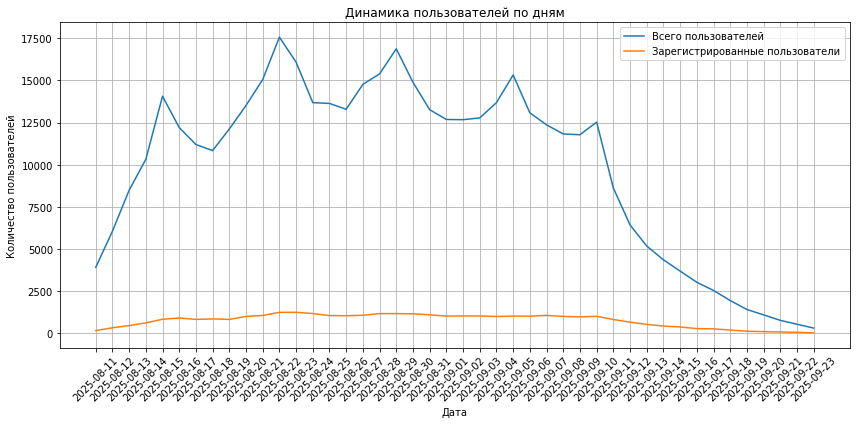

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Всего пользователей')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Зарегистрированные пользователи')

plt.title('Динамика пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [9]:
#Доля зарегистрированных пользователей
daily_stats['registration_share'] = (
    daily_stats['registered_users'] / daily_stats['total_users']
)

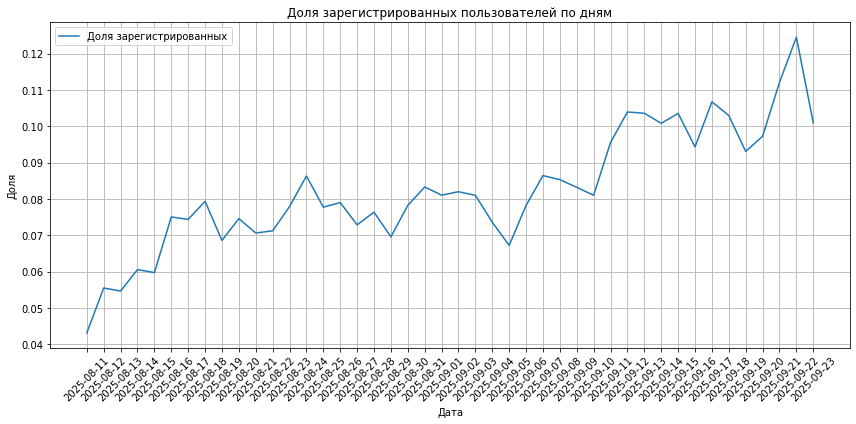

In [10]:
#График доли регистраций
plt.figure(figsize=(12, 6))

plt.plot(daily_stats['session_date'], daily_stats['registration_share'], label='Доля зарегистрированных')

plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### 1.4. Анализ числа просмотренных страниц


In [11]:
#Первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [12]:
page_distribution = (
    first_sessions
    .groupby('page_counter')['session_id']
    .count()
    .reset_index(name='session_count')
    .sort_values(by='page_counter')
)

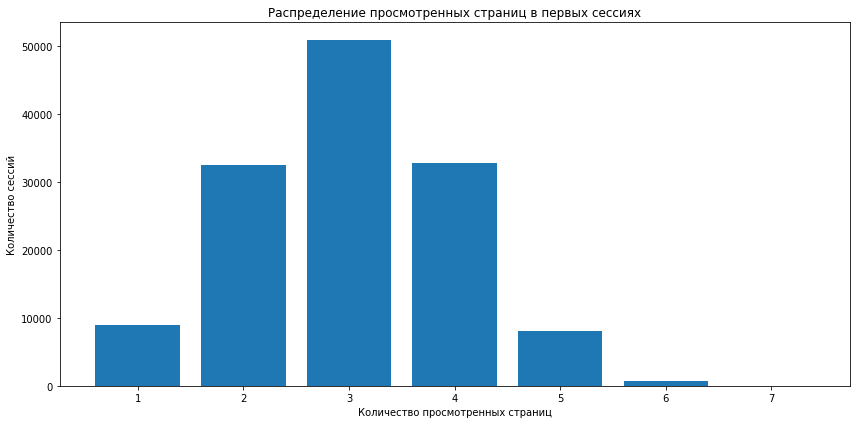

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(page_distribution['page_counter'], page_distribution['session_count'])

plt.title('Распределение просмотренных страниц в первых сессиях')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Будем считать, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.


In [14]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

In [15]:
#Только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [16]:
#Агрегация по дням
daily_good_sessions = (
    first_sessions
    .groupby('session_date')['good_session']
    .mean()
    .reset_index()
)

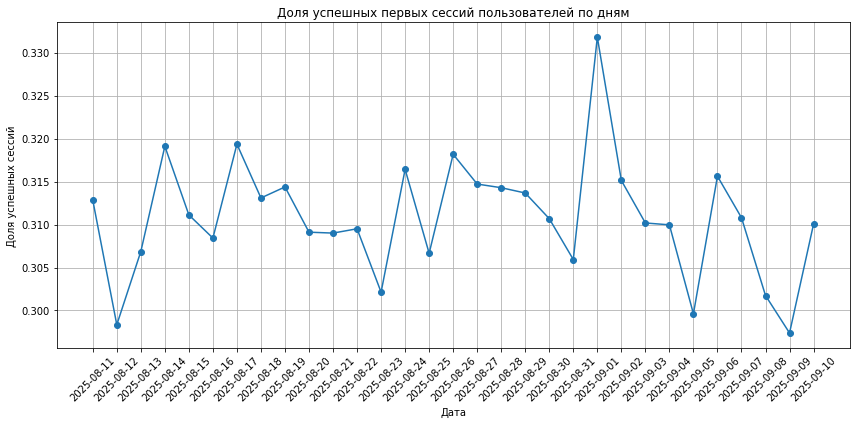

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(daily_good_sessions['session_date'], daily_good_sessions['good_session'], marker='o')

plt.title('Доля успешных первых сессий пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 2. Подготовка к тесту


#### 2.1. Расчёт размера выборки


In [18]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста


In [19]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

Представим, что A/B-тест успешно запущен, и уже доступны данные за первые три дня.
- В датафрейм `sessions_test_part` внесен CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.


In [20]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
print(sessions_test_part.head())

            user_id        session_id session_date     session_start_ts  \
0  3404844B53442747  B4901323BD537E45   2025-10-14  2025-10-14 19:28:49   
1  3A2BF4D364E62D89  216FC619308F8788   2025-10-14  2025-10-14 21:11:04   
2  79CDAE11E32B1597  EDFCE4AC1A504074   2025-10-14  2025-10-14 21:44:03   
3  D6AF8D78297A931F  CF0AC0EEDE92C690   2025-10-14  2025-10-14 19:07:55   
4  37E0CE723AE568E0  2E6ED45E8C86C4E9   2025-10-14  2025-10-14 15:39:44   

  install_date  session_number  registration_flag  page_counter region  \
0   2025-10-14               1                  0             3    CIS   
1   2025-10-14               1                  0             3   MENA   
2   2025-10-14               1                  0             3    CIS   
3   2025-10-14               1                  0             4    CIS   
4   2025-10-14               1                  0             3    CIS   

    device test_group  
0  Android          B  
1   iPhone          A  
2   iPhone          A  
3       

In [21]:
#Кол-во уникальных пользователей в каждой группе
daily_users_group = (
    sessions_test_part
    .groupby('test_group')['user_id']
    .nunique()
    .reset_index(name='unique_users')
)

print(daily_users_group)

  test_group  unique_users
0          A          1477
1          B          1466


In [22]:
#Процентная разница
users_A = daily_users_group.loc[daily_users_group['test_group'] == 'A', 'unique_users'].values[0]
users_B = daily_users_group.loc[daily_users_group['test_group'] == 'B', 'unique_users'].values[0]

percent_diff = 100 * abs(users_A - users_B) / users_A
print(percent_diff)

0.7447528774542993


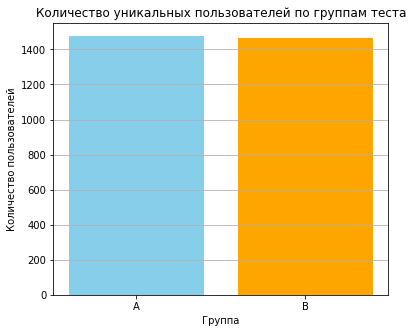

In [23]:
plt.figure(figsize=(6, 5))
plt.bar(daily_users_group['test_group'], daily_users_group['unique_users'], color=['skyblue', 'orange'])

plt.title('Количество уникальных пользователей по группам теста')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.grid(axis='y')
plt.show()

#### 3.2. Проверка пересечений пользователей


In [24]:
#Уникальные пользователи каждой группы
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

In [25]:
#Находим пересечение
users_intersection = users_A & users_B 
num_overlap = len(users_intersection)
print(num_overlap)

0


#### 3.3. Равномерность разделения пользователей по устройствам



In [26]:
# Убираем дублирование пользователей
unique_users = sessions_test_part.drop_duplicates(subset=['user_id'])

# Фильтруем по группам
users_A = unique_users[unique_users['test_group'] == 'A']
users_B = unique_users[unique_users['test_group'] == 'B']

In [27]:
#Рассчитаем доли пользователей по устройствам
device_share_A = users_A['device'].value_counts(normalize=True)
device_share_B = users_B['device'].value_counts(normalize=True)
print(device_share_A)
print(device_share_B)

Android    0.444144
PC         0.249831
iPhone     0.200406
Mac        0.105619
Name: device, dtype: float64
Android    0.455662
PC         0.259891
iPhone     0.183492
Mac        0.100955
Name: device, dtype: float64


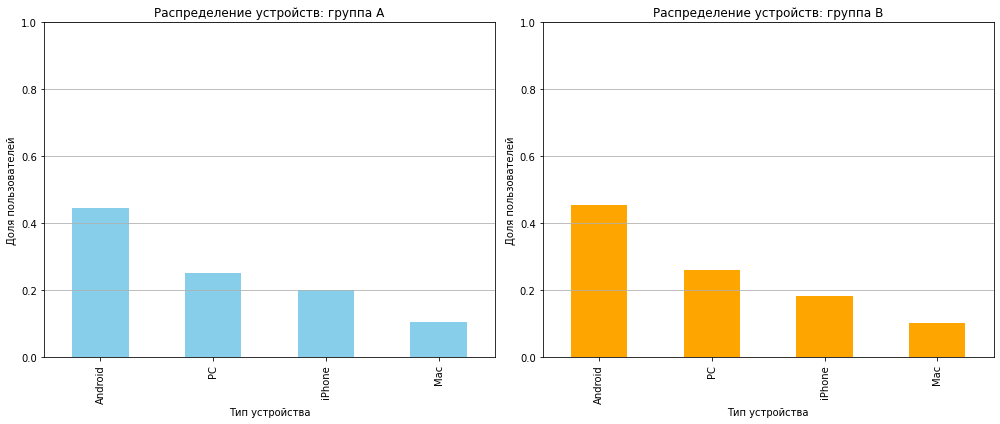

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Группа A
device_share_A.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Распределение устройств: группа A')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля пользователей')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y')

# Группа B
device_share_B.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Распределение устройств: группа B')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Доля пользователей')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам


In [29]:
# Доли пользователей по регионам
region_share_A = users_A['region'].value_counts(normalize=True)
region_share_B = users_B['region'].value_counts(normalize=True)
print(region_share_A)
print(region_share_B)

CIS     0.436019
MENA    0.412322
EU      0.151659
Name: region, dtype: float64
CIS     0.439973
MENA    0.412005
EU      0.148022
Name: region, dtype: float64


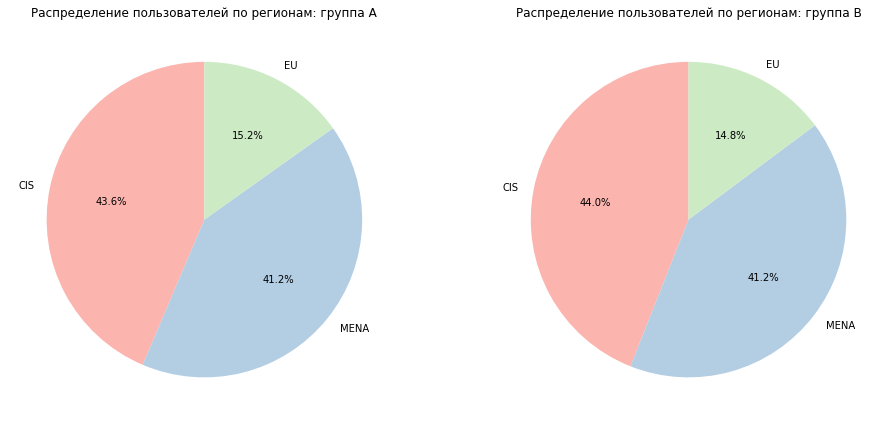

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Группа A
axes[0].pie(region_share_A, labels=region_share_A.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
axes[0].set_title('Распределение пользователей по регионам: группа A')

# Группа B
axes[1].pie(region_share_B, labels=region_share_B.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
axes[1].set_title('Распределение пользователей по регионам: группа B')

plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста



- Количество пользователей в тестовой и контрольной группах практически одинаковое: в группе A — 1477 пользователей, в группе B — 1466. Различие незначительное и находится в пределах ожидаемых случайных отклонений, что свидетельствует о корректном распределении пользователей между группами.
- Пользователи распределены корректно: пересечений между группами нет.
- Распределение пользователей по устройствам и регионам в тестовой и контрольной группах в целом сохраняется и является близким к равномерному. По типам устройств доли пользователей в группах A и B отличаются незначительно (различия составляют менее 2 процентов по каждой категории), что указывает на сопоставимый состав групп. Аналогично, распределение по регионам практически идентично: доли пользователей в сегментах CIS, MENA и EU отличаются менее чем на 1 процент. Таким образом, существенных перекосов в распределении пользователей по устройствам и регионам не наблюдается, группы можно считать сбалансированными по данным категориальным признакам.
- A/B-тест проходит корректно, существенных нарушений не выявлено.

### 4. Проверка результатов A/B-теста

Представим, что A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. 

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [31]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

In [32]:
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик



- Речь идет про вовлечённость пользователя, значит самая логичная метрика - good_session (где пользователь просмотрел ≥ 4 страниц) - целевая метрика
- Нулевая гипотеза (H₀): Новый алгоритм рекомендаций не влияет на вовлечённость пользователей — доля успешных сессий в группах A и B одинакова.
- Альтернативная гипотеза (H₁): Новый алгоритм рекомендаций увеличивает вовлечённость пользователей — доля успешных сессий в группе B выше, чем в группе A.
- Прокси-метрики:
  - Среднее количество просмотренных страниц (page_counter)
  - Доля зарегистрированных пользователей (registration_flag)
  - Количество сессий на пользователя (retention / session_number динамика)
- Барьерные метрики:
  - Возврат пользователей
  - Частота сессий на пользователя
  - Очень короткие сессии
  - Стабильность по регионам/устройствам

#### 4.3. Сравнение доли успешных сессий


In [33]:
#Первые сессии пользователей
first_sessions = sessions_test[sessions_test['session_number'] == 1]

#Доля успешных сессий по группам
conversion_by_group = first_sessions.groupby('test_group')['good_session'].mean()

#Извлекаем значения
conv_A = conversion_by_group['A']
conv_B = conversion_by_group['B']

#Считаем разницу
diff = conv_B - conv_A

print(f'Доля успешных первых сессий:')
print(f'Группа A: {conv_A:.4f}')
print(f'Группа B: {conv_B:.4f}')
print(f'Разница (B - A): {diff:.4f}')

Доля успешных первых сессий:
Группа A: 0.3157
Группа B: 0.3147
Разница (B - A): -0.0011


#### 4.4. Насколько статистически значимо изменение ключевой метрики



In [34]:
import statsmodels.api as sm

#Первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

#Выбираем данные по группам
success_A = first_sessions[first_sessions['test_group'] == 'A']['good_session']
success_B = first_sessions[first_sessions['test_group'] == 'B']['good_session']

#Количество успешных сессий
count = [success_A.sum(), success_B.sum()]

#Общее количество пользователей в группах
nobs = [len(success_A), len(success_B)]

#Проводим z-тест для долей
stat, p_value = sm.stats.proportions_ztest(count, nobs)

print(f'p-value: {p_value:.4f}')

#Вывод
alpha = 0.05
if p_value < alpha:
    print("Изменение статистически значимо: отвергаем нулевую гипотезу.")
else:
    print("Изменение не является статистически значимым: не можем отвергнуть нулевую гипотезу.")

p-value: 0.8433
Изменение не является статистически значимым: не можем отвергнуть нулевую гипотезу.


#### 4.5. Вывод по результатам A/B-эксперимента




 1. Характеристики эксперимента

Период проведения: с 14 октября по 2 ноября 2025 года.
Количество пользователей:
Группа A: 1477; 
Группа B: 1466.
Разбиение на группы выполнено корректно, распределение пользователей по устройствам и регионам сбалансировано. Выборки независимы, пересечений пользователей между группами нет.

2. Влияние нового алгоритма на ключевую метрику

Ключевая метрика: доля успешных первых сессий (good_session ≥ 4 просмотров страниц).
Результаты по группам:
Группа A: 0.3157;
Группа B: 0.3147;
Разница (B − A): −0.0011/
Вывод: внедрение нового алгоритма не привело к заметному росту вовлечённости пользователей — доля успешных сессий в обеих группах практически одинакова.

3. Статистическая значимость эффекта

Проведён z-тест для долей: p-value = 0.8433
Так как p-value значительно выше уровня значимости 0.05, эффект не является статистически значимым.

4. Рекомендация по внедрению

На основании полученных результатов рекомендации по внедрению нового алгоритма пока нет, так как изменения в ключевой метрике отсутствуют.
Рекомендуется проанализировать возможные причины отсутствия эффекта и при необходимости провести дополнительное тестирование с улучшенными гипотезами или сегментацией пользователей.
Продолжать мониторинг прокси- и барьерных метрик (среднее число просмотров страниц, удержание пользователей) для оценки потенциального влияния алгоритма.